In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [2]:

#  LOAD DATASET


file_path = "Global_Cybersecurity_Threats_2015-2024.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [3]:

#  DATA OVERVIEW


print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDataset Info:\n")
print(df.info())

Dataset Shape: (3000, 10)

Column Names:
 Index(['Country', 'Year', 'Attack Type', 'Target Industry',
       'Financial Loss (in Million $)', 'Number of Affected Users',
       'Attack Source', 'Security Vulnerability Type',
       'Defense Mechanism Used', 'Incident Resolution Time (in Hours)'],
      dtype='object')

Missing Values:

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------

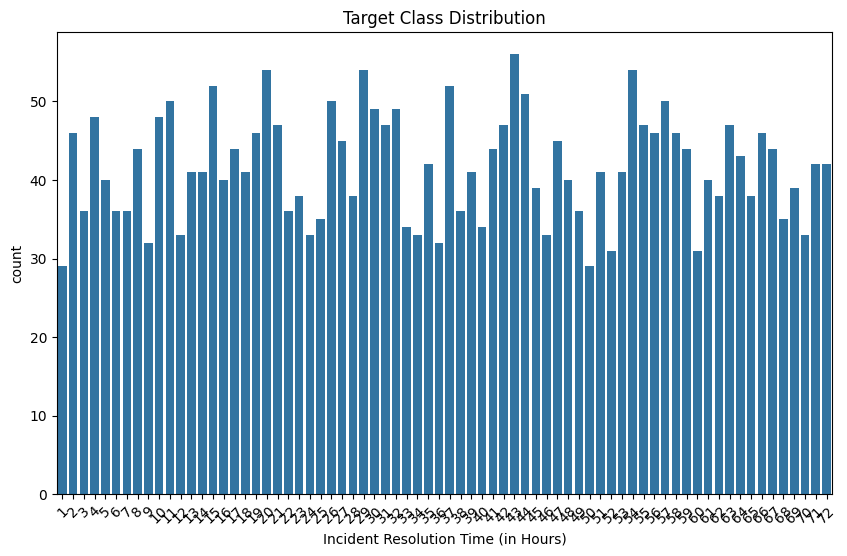

In [4]:

# EXPLORATORY DATA ANALYSIS


# Plot class distribution
target_col = df.columns[-1]   # Adjust if target differs

plt.figure(figsize=(10,6))
sns.countplot(x=df[target_col])
plt.xticks(rotation=45)
plt.title("Target Class Distribution")
plt.show()

In [5]:

#  PREPROCESSING


X = df.drop(columns=[target_col])
y = df[target_col]

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Transform features
X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

# Convert sparse matrices for Naive Bayes
if hasattr(X_train_p, "toarray"):
    X_train_dense = X_train_p.toarray()
    X_test_dense = X_test_p.toarray()
else:
    X_train_dense = X_train_p
    X_test_dense = X_test_p

print("Preprocessing Complete!")

Preprocessing Complete!


In [6]:

#  MODEL TRAINING


models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

results = []

for name, model in models.items():

    if name == "Naive Bayes":
        model.fit(X_train_dense, y_train)
        preds = model.predict(X_test_dense)

    else:
        model.fit(X_train_p, y_train)
        preds = model.predict(X_test_p)

    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds, average="weighted")
    recall = recall_score(y_test, preds, average="weighted")
    f1 = f1_score(y_test, preds, average="weighted")

    results.append([name, accuracy, precision, recall, f1])

    print(f"\n{name}")
    print("Accuracy:", accuracy)
    print(classification_report(y_test, preds))


Naive Bayes
Accuracy: 0.006666666666666667
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.00      0.00      0.00         9
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00         8
           4       0.00      0.00      0.00         9
           5       0.00      0.00      0.00         9
           6       0.00      0.00      0.00         8
           7       0.00      0.00      0.00        10
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00        12
          10       0.00      0.00      0.00         9
          11       0.01      0.17      0.02         6
          12       0.00      0.00      0.00        11
          13       0.00      0.00      0.00         6
          14       0.00      0.00      0.00         6
          15       0.00      0.00      0.00        11
          16       0.00      0.00    

c:\Users\saanv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\saanv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\saanv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo


KNN
Accuracy: 0.02
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.02      0.11      0.04         9
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00         8
           4       0.05      0.22      0.08         9
           5       0.04      0.11      0.06         9
           6       0.00      0.00      0.00         8
           7       0.00      0.00      0.00        10
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00        12
          10       0.05      0.11      0.07         9
          11       0.00      0.00      0.00         6
          12       0.09      0.18      0.12        11
          13       0.00      0.00      0.00         6
          14       0.06      0.17      0.09         6
          15       0.00      0.00      0.00        11
          16       0.00      0.00      0.00         7
       

c:\Users\saanv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\saanv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\saanv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [7]:

# COMPARISON TABLE


comparison_data = []

for row in results:
    comparison_data.append({
        "Model": row[0],
        "Accuracy": round(row[1], 4),
        "Precision": round(row[2], 4),
        "Recall": round(row[3], 4),
        "F1-score": round(row[4], 4)
    })

results_df = pd.DataFrame(comparison_data)

# Reset index for neat display
results_df = results_df.reset_index(drop=True)

print("\nComparison Table")
print(results_df.to_string(index=False))


Comparison Table
              Model  Accuracy  Precision  Recall  F1-score
        Naive Bayes    0.0067     0.0004  0.0067    0.0008
Logistic Regression    0.0033     0.0282  0.0033    0.0047
                KNN    0.0200     0.0303  0.0200    0.0166
                SVM    0.0217     0.0133  0.0217    0.0125


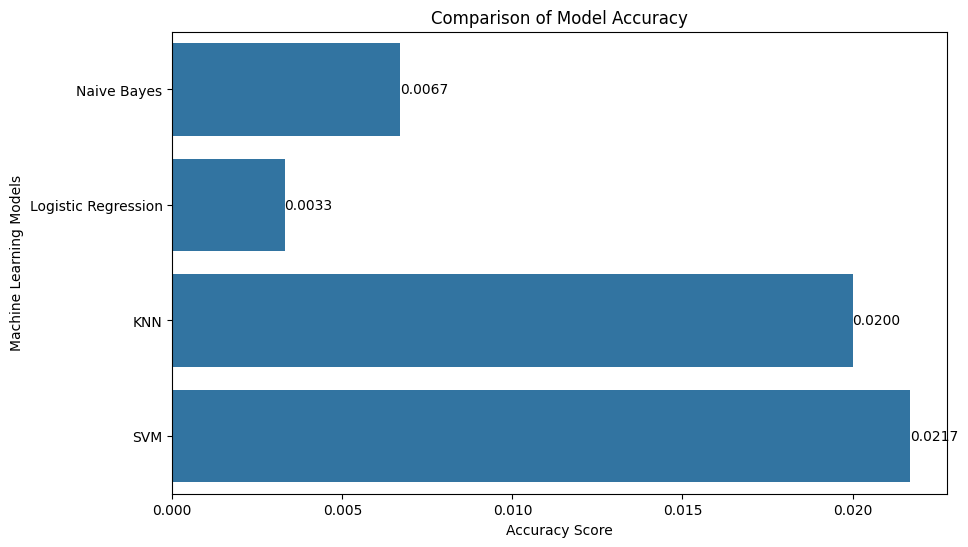

In [8]:

#  VISUALIZATION


plt.figure(figsize=(10,6))

# Accuracy comparison chart
sns.barplot(data=results_df, x="Accuracy", y="Model")

plt.title("Comparison of Model Accuracy")
plt.xlabel("Accuracy Score")
plt.ylabel("Machine Learning Models")

for index, value in enumerate(results_df["Accuracy"]):
    plt.text(value, index, f"{value:.4f}", va="center")

plt.show()

In [9]:

#  HYPERPARAMETER TUNING


from sklearn.model_selection import GridSearchCV

# Logistic Regression Tuning
lr_params = {
    "C": [0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=3,
    scoring="accuracy"
)

lr_grid.fit(X_train_p, y_train)

print("Best Logistic Regression Params:", lr_grid.best_params_)
print("Best Score:", lr_grid.best_score_)

Best Logistic Regression Params: {'C': 0.1, 'solver': 'lbfgs'}
Best Score: 0.015000000000000001


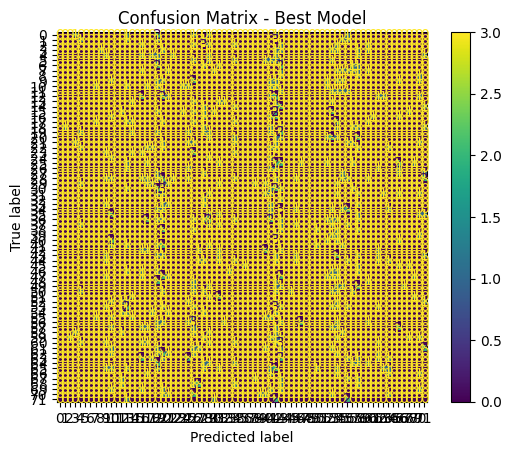

In [10]:

# CONFUSION MATRIX


from sklearn.metrics import ConfusionMatrixDisplay

best_clf = lr_grid.best_estimator_
y_pred_best = best_clf.predict(X_test_p)

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Best Model")
plt.show()

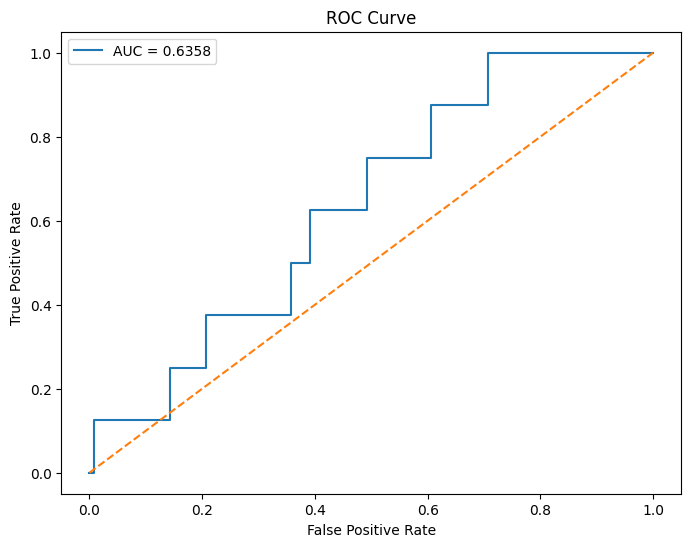

In [11]:

#  ROC-AUC ANALYSIS


from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize target
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# Predict probabilities
if hasattr(best_clf, "predict_proba"):
    y_score = best_clf.predict_proba(X_test_p)
else:
    y_score = best_clf.decision_function(X_test_p)

# ROC for first class
fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_score[:, 0])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [12]:
# =============================
# FEATURE IMPORTANCE
# =============================

feature_names = preprocessor.get_feature_names_out()

coefficients = best_clf.coef_[0]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": coefficients
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print("Top Important Features:")
print(importance_df.head(10))

Top Important Features:
                                              Feature  Importance
15                 cat__Attack Type_Man-in-the-Middle    0.213971
18                     cat__Attack Type_SQL Injection    0.192553
38                    cat__Defense Mechanism Used_VPN    0.191662
30  cat__Security Vulnerability Type_Social Engine...    0.191458
10                                cat__Country_Russia    0.170038
33          cat__Security Vulnerability Type_Zero-day    0.161535
11                                    cat__Country_UK    0.145508
25            cat__Target Industry_Telecommunications    0.092826
28                    cat__Attack Source_Nation-state    0.087727
5                                  cat__Country_China    0.078501


In [13]:
import joblib

joblib.dump(best_clf, "best_cybersecurity_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [15]:
loaded_model = joblib.load("best_cybersecurity_model.pkl")
print("Loaded model:", loaded_model)

Loaded model: LogisticRegression(C=0.1, max_iter=1000)


In [14]:

#BEST MODEL ANALYSIS


best_model = results_df.loc[results_df["Accuracy"].idxmax()]

print("Best Performing Model:\n")
print(best_model.to_string())

print("\nInterpretation:")
print(f"The best-performing algorithm is {best_model['Model']} "
      f"with an accuracy of {best_model['Accuracy']:.4f}. "
      f"It also achieved strong precision, recall, and F1-score, "
      f"making it the most suitable model for this cybersecurity threat classification task.")

Best Performing Model:

Model           SVM
Accuracy     0.0217
Precision    0.0133
Recall       0.0217
F1-score     0.0125

Interpretation:
The best-performing algorithm is SVM with an accuracy of 0.0217. It also achieved strong precision, recall, and F1-score, making it the most suitable model for this cybersecurity threat classification task.
